### Part 1: Factor model setup and run OLS regression

Explaining the asset returns with a five-factor model:
World Equities: MSCI All World market capitalization weighted index.
10 Year US Treasury: Return of 10 year US Treasury Bond
High Yield: BOFA Merrill Lynch Global High Yield Index
Inflation Protection: This is a "style" factor that considers the difference between real and nominal returns, thus balances the need for both. It's the return of the TIPS bond minus the a weighted average of Treasury Bonds.
Currency Protection: This is also an exchange rate factor, capturing the value of the dollar versus a basket of foreign currencies.



In [4]:
#Code in terminal
#pip install cvxpy

#import all the necessary packages
import numpy as np #for numerical array data
import pandas as pd #for tabular data
import matplotlib.pyplot as plt #for plotting purposes

from sklearn.metrics import r2_score

%matplotlib inline
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12

import importlib as imp

import FactorModelLibForMOOC as fm #the code that wraps around the sikitlearn implementations
import config_demo_final as config


import warnings
warnings.filterwarnings('ignore')

In [5]:
all_data = pd.read_csv(config.dataPath)

# converts a column in a pandas DataFrame (all_data) to datetime format using the column name stored in config.dateName:
all_data[config.dateName] = pd.to_datetime(all_data[config.dateName])

all_data = all_data[all_data['Date'] <= '2014-12-01'].copy() ## filters the all_data DataFrame to keep only the rows where the 'Date' column is on or before December 1, 2014, and creates an independent copy to avoid pandas SettingWithCopyWarning issues down the road.

In [6]:
all_data[['Real Estate'] + config.factorName].head(5)

,Real Estate,World Equities,10-year US Treasuries,High Yield,Inflation Protection,Currency Protection
0,-0.014847,-0.020349,0.022922,0.032048,0.006524,-0.003404
1,0.032460,0.010680,0.030014,0.013531,-0.038375,-0.020587
2,-0.005961,0.045804,0.007195,0.025871,-0.023184,-0.042060
3,0.002259,0.036372,0.016973,0.030836,-0.003600,-0.015827
4,0.045025,0.011040,0.054900,0.006743,-0.054282,0.009121


In [7]:
fm.data_time_periods(all_data, config.dateName)

'monthly'

In [8]:
startDate = all_data[config.dateName].min()
endDate = all_data[config.dateName].max()

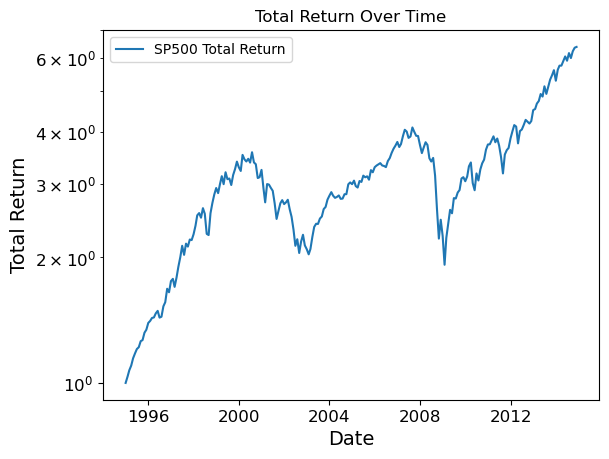

In [9]:
name = 'SP500 Total Return'
fm.plot_returns(all_data, name, flag='Total Return')

In [10]:
pd.options.display.float_format = "{:,.3f}".format #This rounds the display output to 3 decimals
all_data.sort_values('SP500 Total Return').head(3)

,Date,World Equities,10-year US Treasuries,High Yield,Inflation Protection,Currency Protection,U.S. Equity,SP500 Total Return,S&P 500,International Equity,U.S. Treasury 20 years,Corporate Bond,Real Estate,Commodity,TIPS
165,2008-10-01,-0.194,-0.029,-0.084,-0.058,0.087,-0.173,-0.166,-0.168,-0.205,-0.036,-0.070,-0.312,-0.295,-0.087
166,2008-11-01,-0.132,0.085,0.075,-0.078,0.006,-0.163,-0.152,-0.072,-0.112,0.144,0.045,-0.337,-0.176,0.007
169,2009-02-01,-0.131,-0.002,0.033,-0.018,0.028,-0.148,-0.148,-0.106,-0.127,-0.004,-0.019,-0.269,-0.097,-0.020


In [11]:
# OLS Setup:


# Linear Regression (OLS)
Factors = all_data[config.factorName].values
Assets = all_data[config.assetName].values

Asset_RE = Assets[:,0]
Factors_ones = np.concatenate((np.ones((all_data.shape[0],1)),Factors),axis=1)
theory_beta = np.linalg.inv(Factors_ones.T.dot(Factors_ones)).dot(Factors_ones.T).dot(Asset_RE)
print('Dependent variable is SP500 Total Return')
print('Historical Timeperiods ' +  fm.num_to_month(startDate.month) +  " " + str(startDate.year) + " "
      + fm.num_to_month(endDate.month) +  " " + str(endDate.year))
opt = dict()
opt['name_of_reg'] = 'theory_beta'
fm.display_factor_loadings(theory_beta[0], theory_beta[1:], config.factorName, opt)

Dependent variable is SP500 Total Return
Historical Timeperiods January 1995 December 2014
             Intercept  World Equities  10-year US Treasuries  High Yield  \
theory_beta      0.001           1.021                  0.128      -0.004   

             Inflation Protection  Currency Protection  
theory_beta                -0.011                0.397  


In [12]:
#Linear Regression via Scikit-learn
options = fm.create_options()
options['name_of_reg'] = 'sikit-learn OLS'
fm.linear_regression(all_data, 'SP500 Total Return', config.factorName, options)

Dependent Variable is SP500 Total Return
Time period is between January 1995 to December 2014 inclusive   
                 Intercept  World Equities  10-year US Treasuries  High Yield  \
sikit-learn OLS      0.001           1.021                  0.128      -0.004   

                 Inflation Protection  Currency Protection  
sikit-learn OLS                -0.011                0.397  


In [13]:
#Check the fm py file for the linear reg
 #perform linear regression
    #linReg = LinearRegression(fit_intercept=True)
    #linReg.fit(newData[factorNames], newData[dependentVar])

# Check factor correlation:
all_data[config.factorName].corr()

,World Equities,10-year US Treasuries,High Yield,Inflation Protection,Currency Protection
World Equities,1.000,-0.176,0.308,0.332,-0.528
10-year US Treasuries,-0.176,1.000,0.131,-0.616,-0.140
High Yield,0.308,0.131,1.000,0.005,-0.185
Inflation Protection,0.332,-0.616,0.005,1.000,-0.209
Currency Protection,-0.528,-0.140,-0.185,-0.209,1.000


In [14]:
# The first regime "normal", will be months where US Equities had a positive monthly return. The second, "crash" will be months where US Equities had a negative return.
#Here are the factor loadings using the full data set, the normal regime, and the crash regime.

options = fm.create_options()
options['name_of_reg'] = 'OLS full data'
options['return_model'] = False
fm.linear_regression(all_data, 'SP500 Total Return', config.factorName, options)

Dependent Variable is SP500 Total Return
Time period is between January 1995 to December 2014 inclusive   
               Intercept  World Equities  10-year US Treasuries  High Yield  \
OLS full data      0.001           1.021                  0.128      -0.004   

               Inflation Protection  Currency Protection  
OLS full data                -0.011                0.397  


In [15]:
options = fm.create_options()
normal_data = all_data[all_data['SP500 Total Return'] > 0].copy()
options['name_of_reg'] = 'OLS Normal'
options['return_model'] = False
fm.linear_regression(normal_data, 'SP500 Total Return', config.factorName, options)

Dependent Variable is SP500 Total Return
Time period is between January 1995 to December 2014 inclusive   
            Intercept  World Equities  10-year US Treasuries  High Yield  \
OLS Normal      0.007           0.913                  0.201       0.025   

            Inflation Protection  Currency Protection  
OLS Normal                -0.003                0.388  


In [ ]:
options = fm.create_options()
crash_data = all_data[all_data['SP500 Total Return'] <= 0].copy()
options['name_of_reg'] = 'OLS Crash'
options['return_model'] = False
fm.linear_regression(crash_data, 'SP500 Total Return', config.factorName, options)

In [16]:
# Baseline OLS Model
train = all_data[(all_data['Date'] <= '2012-12-01') & (all_data['Date'] >= '1997-03-01')].copy()
test = all_data[all_data['Date'] > '2012-12-01'].copy()


In [17]:
options = fm.create_options()
options['name_of_reg'] = 'OLS full data'
options['return_model'] = True
ols_model_train = fm.linear_regression(train, 'SP500 Total Return', config.factorName, options)

Dependent Variable is SP500 Total Return
Time period is between March 1997 to December 2012 inclusive   
               Intercept  World Equities  10-year US Treasuries  High Yield  \
OLS full data     -0.000           1.007                  0.132      -0.000   

               Inflation Protection  Currency Protection  
OLS full data                 0.058                0.374  


### Part 2: ML methods: Use LASSO regression, and LASSO with cross validation

Penalty term: $\lambda$


In [18]:
# We penalize the sum of the absolute value of the factor loadings. This means that any non-zero factor loading (i.e non-zero coefficient) is penalized in this model.
# The shrinkage parameter lambda is called a hyperparameter which you need to choose via the cross validation procedure.

#let's try different values of adj lambda and see what happens.

options = fm.create_options_lasso()
options['lambda_hat'] = .00001
options['print_loadings'] = True
options['name_of_reg'] = 'LASSO Regression with small Lambda'
fm.lasso_regression(train, 'SP500 Total Return', config.factorName, options)

Dependent Variable is SP500 Total Return
Time period is between March 1997 to December 2012 inclusive   
lambda_hat = 1e-05
                                    Intercept  World Equities  \
LASSO Regression with small Lambda      0.000           0.990   

                                    10-year US Treasuries  High Yield  \
LASSO Regression with small Lambda                  0.063       0.000   

                                    Inflation Protection  Currency Protection  
LASSO Regression with small Lambda                 0.000                0.308  


In [19]:

options = fm.create_options_lasso()
options['lambda_hat'] = .001 #The input alpha value
options['print_loadings'] = True
options['name_of_reg'] = 'LASSO Reg with large Lambda'
fm.lasso_regression(train, 'SP500 Total Return', config.factorName, options)

Dependent Variable is SP500 Total Return
Time period is between March 1997 to December 2012 inclusive   
lambda_hat = 0.001
                             Intercept  World Equities  10-year US Treasuries  \
LASSO Reg with large Lambda      0.003           0.551                 -0.000   

                             High Yield  Inflation Protection  \
LASSO Reg with large Lambda       0.000                 0.000   

                             Currency Protection  
LASSO Reg with large Lambda               -0.000  


### What is the appropriate value of $\lambda$, and by extension, what is the appropirate set of factors to include?
In practice, cross validation selects the correct shrinkage parameter $\lambda$, or in our case $\hat{\lambda}$'s value.  Cross validation tests multiple different values of $\lambda$ and selects the "best one."
First, break the training set into $k$ sections called folds, and define a list of N trial $\lambda$ values.  Take one of the folds, put it to the side and label it validation.  Combining the remaining $k-1$ folds, build a model with each candidate $\lambda$.  This gives you N models.  Calculate the mean squared error of each model on validation fold.  Then, pick the next fold to use a validation.  Again, build the N different models, one for each $\lambda$, and again calculate the mean squared errors on the new validation fold.  Do this $k$ times, one for each of the original folds.

At the end of this, you will have built $n*k$ models.  For each value of $\lambda$ you will have $k$ out of sample errors. 

Finally pick the $\lambda$ which minimizes the average error across across the samples.

Importantly, once you have picked the optimal lambda, you then go build one final model with all of the data and that value of $\lambda$.  That is your final model!

There is not a consensus of how many folds to pick, but 5 will work for our purposes.

In [21]:
options = fm.create_options_cv_lasso()
options['name_of_reg'] = 'CV Lasso'
options['max_lambda_hat'] = .001 #This specifies the maximum Alpha value tested by cross validation, minimum value is zero
options['return_model'] = True
options['n_folds'] = 5 #This states the number of folds
lasso_model_train = fm.cross_validated_lasso_regression(train, 'SP500 Total Return', config.factorName, options)

Dependent Variable is SP500 Total Return
Time period is between March 1997 to December 2012 inclusive   
Best lambda_hat = 1.6667957547420788e-05
          Intercept  World Equities  10-year US Treasuries  High Yield  \
CV Lasso      0.000           0.977                  0.036       0.000   

          Inflation Protection  Currency Protection  
CV Lasso                -0.000                0.272  


### Elastic Net

Ridge regression, which is an even older version of penalized regression. It also shrinks factor loadings, but does not set them to zero. Ridge's claim to fame is that it shrinks the coefficients of highly correlated factors. This can be useful if you have many versions of roughly the same factor. Instead of finding the "best version" of the factor, you may want to use a average.

More recently, practitioners combined the LASSO and Ridge, called an Elastic Net, and it can provide the benefits of both methods.

Importantly, the ridge regression penalty is most valuable when the factors are highly correlated. 

In [22]:
options = fm.create_options_cv_elastic_net()
options['name_of_reg'] = 'CV Elastic Net'
options['max_lambda_hat'] = .01
options['n_folds'] = 5
options['return_model'] = True
el_model_train = fm.cross_validated_elastic_net_regression(train, 'SP500 Total Return', config.factorName, options)

Dependent Variable is SP500 Total Return
Time period is between March 1997 to December 2012 inclusive   
Best lambda_hat = 1.759702749929848e-05
Best l1 ratio = 0.9378947894736842
                Intercept  World Equities  10-year US Treasuries  High Yield  \
CV Elastic Net      0.000           0.976                  0.036       0.000   

                Inflation Protection  Currency Protection  
CV Elastic Net                -0.000                0.271  


### Constrained regression: Best Subset Regression 
It attempts to find the linear model subject to the constraint that only "x" factor loadings can be nonzero. In this case, "x" is an integer the user defines.

In short, we are using the vector z to keep track of which factor loadings the model picks to be non-zero.  The elements of z can only be zero or 1.  So the first constraint (on the left) says that you can have at maximum only max_vars elements of z equal to 1.  The next two constraints enforce the condition that if an element of z is equal to 0, then the corresponding factor loading in $\beta$ must be equal to zero.  The second constraint says that if an element of z is equal to zero, then the corresponding element of $\beta$ must be less than or equal to zero.  Similarly, the third constraint says that if an element of z is equal to zero, the corresponding element of $\beta$ must be greater than or equal to zero.  Combined, those two constraints imply that the corresponding element of $\beta$ must be equal to zero.  If the element of z is equal to 1, then the constraints say the corresponding element of $\beta$ is between -M and M.  If M is large enough, this constraint is not binding.

In this notebook we'll call the "best_subset_regression" function from the library FactorModelLibForMOOC which has already coded this function.   
The function "best_subset_regression" uses the cvxpy library to build the model.

In [24]:
#run the Best Subset regression with with maxVars=2
# in terminal: pip install ecos
options = fm.create_options_best_subset()
options['max_vars'] = 2
options['name_of_reg'] = 'Best Subset with maxVars = 2'
fm.best_subset_regression(train, 'SP500 Total Return', config.factorName, options)

Dependent Variable is SP500 Total Return
Time period is between March 1997 to December 2012 inclusive   
Max Number of Non-Zero Variables is 2
                              Intercept  World Equities  \
Best Subset with maxVars = 2      0.000           0.992   

                              10-year US Treasuries  High Yield  \
Best Subset with maxVars = 2                  0.000       0.000   

                              Inflation Protection  Currency Protection  
Best Subset with maxVars = 2                 0.000                0.324  


In [25]:
options = fm.create_options_best_subset()
options['max_vars'] = 3
options['return_model'] = True
options['name_of_reg'] = 'Best Subset with maxVars = 3'
best_subset_3 = fm.best_subset_regression(train, 'SP500 Total Return', config.factorName, options)

Dependent Variable is SP500 Total Return
Time period is between March 1997 to December 2012 inclusive   
Max Number of Non-Zero Variables is 3
                              Intercept  World Equities  \
Best Subset with maxVars = 3     -0.000           1.009   

                              10-year US Treasuries  High Yield  \
Best Subset with maxVars = 3                  0.104       0.000   

                              Inflation Protection  Currency Protection  
Best Subset with maxVars = 3                 0.000                0.363  


### Forecasting Expected Returns
For now, we'll use the following assumptions.

 * Global Equities: 8%
 * 10-Year Treasury Bonds: 2%
 * High Yield Bonds: 5%
 * Inflation Protection: -.3%
 * Currency Protection: 0%

How do we turn this into an annualized expected return?  Simple, we take the (monthly) version of our yearly factor returns, and use them as inputs to our model.  Then we multiply by 12 (to annualize).

In [26]:
models = [ols_model_train, lasso_model_train, el_model_train, best_subset_3]

comparison = pd.DataFrame(np.zeros((4, 7)), columns=['Intercept'] + config.factorName + 
                          ['Implied Expected Return S&P 500 (Annual)'])
expected_returns = pd.DataFrame(np.array([[.08/12, .02/12, .05/12, -.003/12, 0/12]]), columns=config.factorName)

for i in range(len(models)):
    model = models[i]
    comparison.loc[i,'Intercept'] = model.intercept_
    comparison.loc[i, config.factorName] = model.coef_
    comparison.loc[i, 'Implied Expected Return S&P 500 (Annual)'] = 12*model.predict(expected_returns)
    
comparison.index = ['OLS', 'LASSO', 'Elastic Net', 'Best Subset']

In [27]:
comparison

,Intercept,World Equities,10-year US Treasuries,High Yield,Inflation Protection,Currency Protection,Implied Expected Return S&P 500 (Annual)
OLS,-0.000,1.007,0.132,-0.000,0.058,0.374,0.078
LASSO,0.000,0.977,0.036,0.000,-0.000,0.272,0.082
Elastic Net,0.000,0.976,0.036,0.000,-0.000,0.271,0.082
Best Subset,-0.000,1.009,0.104,0.000,0.000,0.363,0.080


In [28]:
models = [ols_model_train, lasso_model_train, el_model_train, best_subset_3]
predictions = pd.DataFrame(np.zeros((4,1)), columns=['R^2 on Testing Set'])

for i in range(len(models)):
    model = models[i]
    predictions.loc[i, 'R^2 on Testing Set'] = r2_score(test['SP500 Total Return'],
                                                        model.predict(test[config.factorName]))
predictions.index = ['OLS', 'LASSO', 'Elastic Net', 'Best Subset']

In [29]:
predictions

,R^2 on Testing Set
OLS,0.856
LASSO,0.858
Elastic Net,0.858
Best Subset,0.862


### Part 3.  Harvard 5 Factor Study Analysis for Multiple Assets

 For each asset defined below, we run the 5 fold cross validated LASSO regression and calculate the factor loadings and intercept.  Let's see if we can generate any insights.

1) US Equities: Total Return of S&P 500

2) International Equities: Total Return of MSCI World EX US Index

3) Treasury Bond 20 Year: Return of 20 Year US Treasury Bond

4) Corporate Bonds: BofA Merrill Lynch US Corp Master Total Return Index

5) Real Estate: US-DS Real Estate Total Return Index

6) Commodity: GSCI Total Return Minus T-bill

7) TIPS: Barclays US Treasury Inflation-Linked Bond Index (same index as when calculating inflation protection)

In [31]:
names = config.assetName

expected_returns = pd.DataFrame(np.array([[.08/12, .02/12, .05/12, -.003/12, 0/12]]), columns=config.factorName)

factor_matrix = pd.DataFrame(np.zeros((4, 7)), columns=['Intercept'] + config.factorName + 
                          ['Implied Expected (Annual) Return'])

for i in range(len(names)):
    options = fm.create_options_cv_lasso()
    options['name_of_reg'] = 'CV Lasso'
    options['max_lambda_hat'] = .001 #This specifies the maximum Alpha value tested by cross validation, minimum value is zero
    options['return_model'] = True
    options['print_loadings'] = False
    options['n_folds'] = 5 #This states the number of folds
    data = all_data[[names[i]] + config.factorName + ['Date']].copy()
    data = data[(data['Date'] >= '1997-03-01') & (data['Date'] <= '2012-12-01')].copy()
    data = data.dropna()
    model = fm.cross_validated_lasso_regression(data, names[i], config.factorName, options)
    
    factor_matrix.loc[i,'Intercept'] = model.intercept_
    factor_matrix.loc[i, config.factorName] = model.coef_
    factor_matrix.loc[i, 'Implied Expected (Annual) Return'] = 12*model.predict(expected_returns)
    
factor_matrix.index = names

In [32]:
factor_matrix

,Intercept,World Equities,10-year US Treasuries,High Yield,Inflation Protection,Currency Protection,Implied Expected (Annual) Return
SP500 Total Return,0.000,0.977,0.036,0.000,-0.000,0.272,0.082
International Equity,0.000,0.932,-0.085,0.023,-0.018,-0.323,0.077
U.S. Treasury 20 years,-0.000,-0.000,1.340,0.026,-0.000,0.098,0.025
Corporate Bond,0.002,0.081,0.566,0.074,0.234,-0.004,0.039
Real Estate,0.007,0.531,0.000,0.000,0.000,-0.000,0.123
Commodity,0.003,0.215,0.000,-0.057,0.841,-0.992,0.043
TIPS,0.000,0.002,0.958,0.000,0.939,-0.000,0.019
